In [13]:
import tensorflow as tf # type: ignore
import matplotlib.pyplot as plt
import numpy as np
import os
from pathlib import Path
from tensorflow.keras.preprocessing.image import ImageDataGenerator # type: ignore
from PIL import Image
import imgaug.augmenters as iaa

In [14]:
path = Path('Dataset')

In [15]:
batch_size = 64

In [16]:
seq = iaa.Sequential([
    iaa.Resize((256, 256)),  
    iaa.Sometimes(0.5, iaa.GaussianBlur(sigma=(0, 0.5))), 
    iaa.Sometimes(0.5, iaa.AdditiveGaussianNoise(scale=(0, 0.05*255))),  
    iaa.Sometimes(0.5, iaa.LinearContrast((0.75, 1.5))),  
    iaa.Sometimes(0.5, iaa.Multiply((0.8, 1.2))), 
    iaa.Sometimes(0.5, iaa.Affine(
        rotate=(-10, 10), 
        shear=(-5, 5), 
        scale=(0.8, 1.2)  
    ))
])

def augment_images(images):
    if images.ndim == 3:
        return seq(image=images)
    else:
        return seq(images=images) 

data_gen_augmented = ImageDataGenerator(
    rescale=1./255,
    preprocessing_function=augment_images
)

data_augmented = data_gen_augmented.flow_from_directory(
    path,
    target_size=(256, 256),
    batch_size=batch_size,
    class_mode='categorical'
)

Found 69799 images belonging to 29 classes.


In [17]:
class_indices = data_augmented.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.1442754].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.4617285].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.035486].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.0295824].


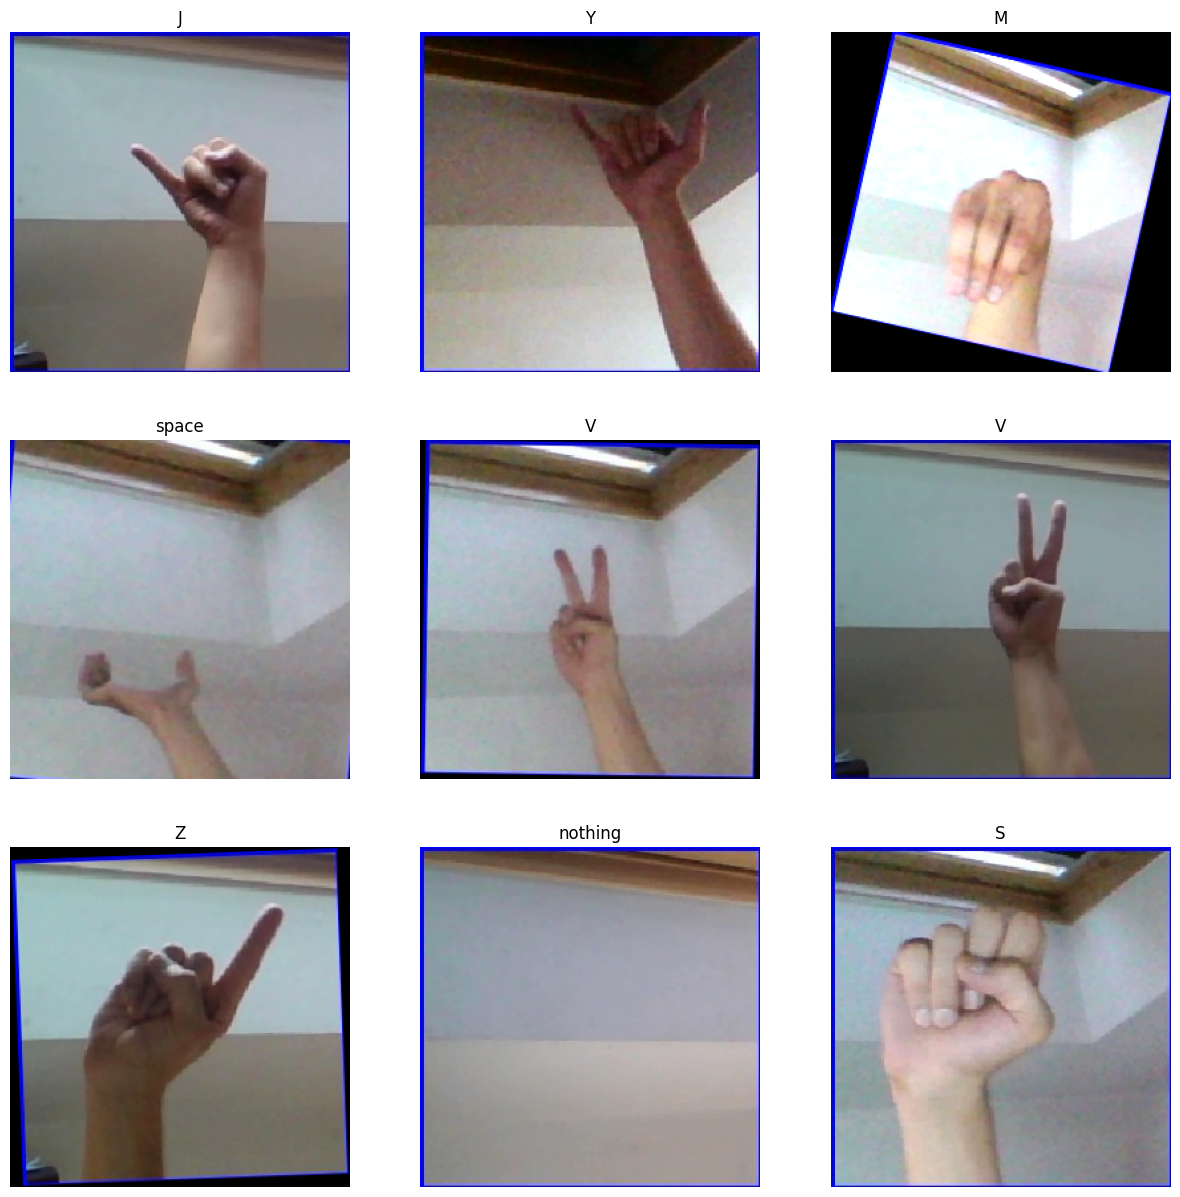

In [18]:
def show_batch(generator):
    x_batch, y_batch = next(generator)
    plt.figure(figsize=(15, 15))
    
    for i in range(9):
        plt.subplot(3, 3, i + 1)
        plt.imshow(x_batch[i])
        
        class_idx = np.argmax(y_batch[i])
        class_name = idx_to_class[class_idx]
        
        plt.title(class_name)
        plt.axis('off')
    
    plt.show()
    
show_batch(data_augmented)